# Topic Modelling — Zero-shot BERTopic on 13 financial categories

Pipeline: LSA summarisation (cached) | MiniLM embeddings (cached) | BERTopic with zero-shot topic list | 2D cluster viz | save model | inference with per-category probability.

**Cache rule**: in `SAMPLE` mode we never write to the full-data cache files.

In [1]:
import warnings
from pathlib import Path
import os

import numpy as np
import polars as pl
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.lsa import LsaSummarizer

from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

from transformers import AutoTokenizer, AutoModelForCausalLM

warnings.filterwarnings('ignore')

CWD = Path.cwd().parent
DATA_DIR = os.path.join(CWD, 'data')
MODEL_DIR = os.path.join(CWD, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

NEWS_PATH = os.path.join(DATA_DIR, 'preprocessed', 'subset_news.parquet')
DEVICE = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Device: {DEVICE}')

/opt/anaconda3/envs/ie_env/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.3.0) or chardet (7.4.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


Device: mps


In [2]:
# Toggle: True = 1k-row in-memory test (never touches full caches).
SAMPLE = True
N_SAMPLE = 1000
WRITE_CACHE = not SAMPLE

# Full-data cache paths
SUMMARIES_PATH  = os.path.join(DATA_DIR, 'predictions', 'lsa_summaries.parquet')
ARTICLE_EMB_PATH = os.path.join(DATA_DIR, 'preprocessed', 'article_embeddings.npy')
ARTICLE_IDS_PATH = os.path.join(DATA_DIR, 'preprocessed', 'article_embedding_ids.parquet')

# Model output (suffixed in sample mode so we don't clobber a full run).
suffix = '_sample' if SAMPLE else ''
TOPIC_MODEL_DIR = os.path.join(MODEL_DIR, f'bertopic_zeroshot{suffix}')

print('SAMPLE:', SAMPLE, '| WRITE_CACHE:', WRITE_CACHE)
print('Topic model dir:', TOPIC_MODEL_DIR)

SAMPLE: True | WRITE_CACHE: False
Topic model dir: /Users/armandhubler/Documents/coding_project/nlp_project/models/bertopic_zeroshot_sample


In [3]:
POOL = [
    'AAPL','MSFT','GOOG','GOOGL','AMZN','TSLA','META','NVDA','AMD','INTC','CRM','NFLX',
    'ADBE','PYPL','UBER','SQ','SHOP','ZM','SNAP','COIN','PLTR','ORCL',
    'QQQ','SPY','DIA','IWM','T','VZ',
    'JPM','GS','MS','WFC','BAC','C',
    'XOM','CVX',
    'JNJ','PFE','MRNA','GILD','MRK','UNH','ABT',
    'WMT','COST','TGT','HD','KO','PEP','SBUX','MCD',
    'BA','GE','CAT','MMM','DIS','CMCSA','V','MA',
    'MU','QCOM','TXN','AVGO','F','GM',
]

df = pl.read_parquet(NEWS_PATH).filter(pl.col('Stock_symbol').is_in(POOL))
print(f'Full filtered df: {df.shape[0]:,} rows')

if SAMPLE:
    work = df.sample(n=min(N_SAMPLE, df.shape[0]), seed=42)
else:
    work = df
print(f'Working set: {work.shape[0]:,} rows')
work.head(2)

Full filtered df: 139,522 rows
Working set: 1,000 rows


id,Date,Article_title,Stock_symbol,Url,Publisher,Author,Article,Lsa_summary,Luhn_summary,Textrank_summary,Lexrank_summary,date_parsed
u32,str,str,str,str,str,str,str,str,str,str,str,date
113613,"""2019-05-09 00:00:00 UTC""","""Financial Sector Update for 05…","""WFC""","""https://www.nasdaq.com/article…",null,null,"""Top Financial Stocks: JPM: -0.…","""USB: Flat Financial giants wer…","""The firm reported Q1 non-GAAP …","""The firm reported Q1 non-GAAP …","""Top Financial Stocks: USB: Fla…",2019-05-09
44483,"""2023-08-14 00:00:00 UTC""","""Dow Analyst Moves: GS""","""GS""","""https://www.nasdaq.com/article…",null,null,"""The latest tally of analyst op…","""VIDEO: Dow Analyst Moves: GS T…","""VIDEO: Dow Analyst Moves: GS T…","""VIDEO: Dow Analyst Moves: GS T…","""VIDEO: Dow Analyst Moves: GS T…",2023-08-14


## 1. LSA summaries (id-keyed cache)

If a summary for `id` already exists in the cache file, reuse it. Otherwise compute and (only in full mode) persist.

In [4]:
_lsa = LsaSummarizer()

def summarise(article: str, n: int = 3) -> str:
    """LSA-summarise one article into n sentences."""
    parser = PlaintextParser.from_string(article or '', Tokenizer('english'))
    return ' '.join(str(s) for s in _lsa(parser.document, n))


def get_summaries(work_df: pl.DataFrame) -> pl.DataFrame:
    """Return work_df with `lsa_summary` column, reusing SUMMARIES_PATH by id."""
    if os.path.exists(SUMMARIES_PATH):
        cached = pl.read_parquet(SUMMARIES_PATH)
    else:
        cached = pl.DataFrame({'id': [], 'lsa_summary': []}, schema={'id': work_df.schema['id'], 'lsa_summary': pl.Utf8})

    have = set(cached['id'].to_list())
    missing = work_df.filter(~pl.col('id').is_in(have))
    print(f'Summaries — cached: {len(have):,} | need: {missing.shape[0]:,}')

    if missing.shape[0]:
        rows = [
            {'id': r['id'], 'lsa_summary': summarise(r['Article'])}
            for r in tqdm(missing.iter_rows(named=True), total=missing.shape[0], desc='LSA')
        ]
        cached = pl.concat([cached, pl.DataFrame(rows)])
        if WRITE_CACHE:
            cached.write_parquet(SUMMARIES_PATH)
            print(f'Wrote {cached.shape[0]:,} summaries → {SUMMARIES_PATH.name}')
        else:
            print('SAMPLE mode: summaries kept in memory only')

    return work_df.join(cached, on='id', how='left')

work = get_summaries(work)
print(work.select(['id', 'lsa_summary']).head(2))

Summaries — cached: 139,522 | need: 0
shape: (2, 2)
┌────────┬─────────────────────────────────┐
│ id     ┆ lsa_summary                     │
│ ---    ┆ ---                             │
│ u32    ┆ str                             │
╞════════╪═════════════════════════════════╡
│ 113613 ┆ Early movers include: (-) Gree… │
│ 44483  ┆ Goldman Sachs Group also comes… │
└────────┴─────────────────────────────────┘


## 2. Sentence embeddings (id-keyed cache)

One embedding per article (the prefixed LSA summary). Cache aligns `article_embeddings.npy` with `article_embedding_ids.parquet`.

In [5]:
from sentence_transformers import SentenceTransformer

EMBED_DIR = os.path.join(MODEL_DIR, 'all-MiniLM-L6-v2')
if os.path.exists(EMBED_DIR):
    embed_model = SentenceTransformer(str(EMBED_DIR), device=DEVICE)
else:
    embed_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2', device=DEVICE)
    embed_model.save(str(EMBED_DIR))

print('Embed dim:', embed_model.get_sentence_embedding_dimension())

Embed dim: 384


In [6]:
def build_doc(row: dict) -> str:
    """Metadata-prefixed summary — the actual text we embed and topic-model."""
    return f"[{row['Stock_symbol']}] [{row['Date']}] {row['Article_title']} | {row['Lsa_summary']}"


def get_embeddings(work_df: pl.DataFrame) -> tuple[list[str], np.ndarray]:
    """Return (docs, emb[N,D]) aligned to work_df order; reuse cache by id."""
    docs = [build_doc(r) for r in work_df.iter_rows(named=True)]
    ids = work_df['id'].to_list()

    cached_ids, cached_emb = [], None
    if os.path.exists(ARTICLE_EMB_PATH) and os.path.exists(ARTICLE_IDS_PATH):
        cached_ids = pl.read_parquet(ARTICLE_IDS_PATH)['id'].to_list()
        cached_emb = np.load(ARTICLE_EMB_PATH)

    id_to_pos = {i: p for p, i in enumerate(cached_ids)}
    have_mask = np.array([i in id_to_pos for i in ids])
    print(f'Embeddings — cached hit: {have_mask.sum():,} / {len(ids):,}')

    missing_idx = np.where(~have_mask)[0]
    new_emb = np.zeros((len(missing_idx), embed_model.get_sentence_embedding_dimension()), dtype='float32')
    if len(missing_idx):
        new_docs = [docs[i] for i in missing_idx]
        new_emb = embed_model.encode(new_docs, batch_size=32, show_progress_bar=True).astype('float32')

        if WRITE_CACHE:
            if cached_emb is None:
                merged_emb = new_emb
                merged_ids = [ids[i] for i in missing_idx]
            else:
                merged_emb = np.vstack([cached_emb, new_emb])
                merged_ids = cached_ids + [ids[i] for i in missing_idx]
            np.save(ARTICLE_EMB_PATH, merged_emb)
            pl.DataFrame({'id': merged_ids}).write_parquet(ARTICLE_IDS_PATH)
            print(f'Wrote {merged_emb.shape[0]:,} embeddings → {ARTICLE_EMB_PATH.name}')
            cached_ids, cached_emb = merged_ids, merged_emb
            id_to_pos = {i: p for p, i in enumerate(cached_ids)}
        else:
            print('SAMPLE mode: embeddings kept in memory only')

    out = np.zeros((len(ids), new_emb.shape[1] if len(missing_idx) else cached_emb.shape[1]), dtype='float32')
    for k, i in enumerate(ids):
        if i in id_to_pos:
            out[k] = cached_emb[id_to_pos[i]]
        else:
            # found in-memory only (sample mode path)
            pos = list(missing_idx).index(k)
            out[k] = new_emb[pos]
    return docs, out


docs, embeddings = get_embeddings(work)
print('docs:', len(docs), '| embeddings:', embeddings.shape)

Embeddings — cached hit: 1,000 / 1,000
docs: 1000 | embeddings: (1000, 384)


## 3. BERTopic — zero-shot onto 13 target categories

We pass rich category descriptions as `zeroshot_topic_list` so every document gets matched to one of the 13 anchors by cosine similarity. Docs that don't clear the similarity threshold fall into HDBSCAN residuals (usually few; we then reduce to 13).

In [ ]:
# Augment topics with LLM for non predefined topic descriptions.
QWEN_DIR = os.path.join(MODEL_DIR, 'qwen2.5-1.5b-instruct')

if os.path.exists(QWEN_DIR):
    qwen_tokenizer = AutoTokenizer.from_pretrained(QWEN_DIR)
    qwen_model = AutoModelForCausalLM.from_pretrained(QWEN_DIR)
else:
    qwen_tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen2.5-1.5B-Instruct')
    qwen_model = AutoModelForCausalLM.from_pretrained('Qwen/Qwen2.5-1.5B-Instruct')
    qwen_tokenizer.save_pretrained(QWEN_DIR)
    qwen_model.save_pretrained(QWEN_DIR)

qwen_model.to(DEVICE)


SYSTEM_PROMPT = """You are a financial news assistant. Expand a short topic label into a rich one-line description with specific keywords, entities, and terms relevant to financial news.

Examples:
- "Big Tech & Software" → Big tech and enterprise software: Apple, Microsoft, Google, Meta, Amazon, cloud, SaaS, platforms, services
- "Semiconductors & Hardware" → Semiconductors and hardware: Nvidia, AMD, Intel, TSMC, chips, GPUs, wafers, foundries, processors"""


def generate_topic_description(topic: str) -> str:
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": f'Expand this topic: "{topic}"'},
    ]
    text = qwen_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    input_ids = qwen_tokenizer(text, return_tensors='pt').input_ids.to(qwen_model.device)

    output_ids = qwen_model.generate(
        input_ids,
        max_new_tokens=300,
        do_sample=False,
        pad_token_id=qwen_tokenizer.eos_token_id,
    )
    # Decode only the newly generated tokens, not the prompt
    new_tokens = output_ids[0][input_ids.shape[-1]:]
    return qwen_tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

generate_topic_description("AI and healthcare")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

'Artificial Intelligence (AI) in Healthcare: Advancements, Applications, and Impact on Diagnostics, Treatment, and Patient Care'

In [ ]:
# We will use the model in the back end but for now we will use these hard coded descriptions.

TOPIC_LABELS = {
    0:  'Big Tech & Software',
    1:  'Semiconductors & Hardware',
    2:  'AI & Machine Learning',
    3:  'Earnings & Guidance',
    4:  'Macro & Fed Policy',
    5:  'Oil, Gas & Energy',
    6:  'Biotech & Pharma',
    7:  'Crypto & Fintech',
    8:  'EV & Clean Energy',
    9:  'M&A & IPO',
    10: 'Dividends & Income',
    11: 'Consumer & Retail',
    12: 'Markets & Sentiment',
}

# Rich descriptions drive better zero-shot matching than bare labels.
TOPIC_DESCRIPTIONS = {
    0:  'Big tech and enterprise software: Apple, Microsoft, Google, Meta, Amazon, cloud, SaaS, platforms, services',
    1:  'Semiconductors and hardware: Nvidia, AMD, Intel, TSMC, chips, GPUs, wafers, foundries, processors',
    2:  'Artificial intelligence and machine learning: ChatGPT, OpenAI, LLMs, generative AI, deep learning, inference, data centers',
    3:  'Earnings and guidance: quarterly results, EPS, revenue beat or miss, outlook, forecast, margins, estimates',
    4:  'Macro and Federal Reserve policy: inflation, interest rates, FOMC, CPI, Treasury yields, recession, GDP',
    5:  'Oil, gas and energy: crude oil, OPEC, Exxon, Chevron, refineries, natural gas, pipelines, petroleum',
    6:  'Biotech and pharmaceuticals: drug approval, FDA, clinical trials, vaccines, cancer therapy, pharma companies',
    7:  'Cryptocurrency and fintech: bitcoin, ethereum, blockchain, Coinbase, DeFi, PayPal, digital assets, stablecoins',
    8:  'Electric vehicles and clean energy: Tesla, Rivian, batteries, charging, solar, renewables, lithium, emissions',
    9:  'Mergers, acquisitions and IPOs: takeovers, buyouts, SPACs, public offerings, valuations, private equity deals',
    10: 'Dividends and income investing: dividend yield, payout, buybacks, share repurchase, shareholder returns',
    11: 'Consumer and retail: retail sales, Walmart, e-commerce, holiday shopping, consumer demand, prices',
    12: 'Markets and sentiment: bull market, bear market, rally, selloff, volatility, VIX, S&P 500, Dow, indexes',
}

assert set(TOPIC_LABELS) == set(TOPIC_DESCRIPTIONS)
zeroshot_list = [TOPIC_DESCRIPTIONS[k] for k in sorted(TOPIC_DESCRIPTIONS)]
ordered_labels = [TOPIC_LABELS[k] for k in sorted(TOPIC_LABELS)]

# Export json with topic as keys and descriptions as values for use in back end
TOPICS = {k: {'label': TOPIC_LABELS[k], 'description': TOPIC_DESCRIPTIONS[k]} for k in TOPIC_LABELS}

import json
with open(os.path.join(DATA_DIR, 'topic_descriptions.json'), 'w') as f:
    json.dump(TOPICS, f)

In [ ]:
n_docs = len(docs)
min_cluster = max(5, min(30, n_docs // 50))

umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0,
                  metric='cosine', random_state=42, low_memory=True)
hdbscan_model = HDBSCAN(min_cluster_size=min_cluster, metric='euclidean',
                        cluster_selection_method='eom', prediction_data=True)

EXTRA_STOPS = [
    'utc', 'summary', 'stock', 'stocks', 'inc', 'corp', 'company', 'nasdaq',
    'shares', 'share', 'said', 'also', 'new', 'would', 'could', 'year', 'years',
    *[t.lower() for t in POOL],
]
vectorizer = CountVectorizer(stop_words='english', min_df=2, ngram_range=(1, 2))
vectorizer.stop_words = list(set(vectorizer.get_stop_words()) | set(EXTRA_STOPS))

topic_model = BERTopic(
    embedding_model=embed_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer,
    zeroshot_topic_list=zeroshot_list,
    zeroshot_min_similarity=0.35,
    min_topic_size=min_cluster,
    calculate_probabilities=False,
    verbose=True,
)

topics, _ = topic_model.fit_transform(docs, embeddings=embeddings)
topics = np.asarray(topics)
print(f'Raw topics found: {len(set(topics)) - (1 if -1 in topics else 0)} (+outliers)')

2026-04-12 19:19:53,128 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
2026-04-12 19:22:04,079 - BERTopic - Dimensionality - Completed ✓
2026-04-12 19:22:04,087 - BERTopic - Zeroshot Step 1 - Finding documents that could be assigned to either one of the zero-shot topics
2026-04-12 19:22:05,317 - BERTopic - Zeroshot Step 1 - Completed ✓
2026-04-12 19:22:29,959 - BERTopic - Cluster - Start clustering the reduced embeddings
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling par

Raw topics found: 343 (+outliers)


In [9]:
# In zero-shot mode BERTopic sets Name == the description for matched topics;
# residual HDBSCAN topics get 'N_word1_word2_...' as Name.
info = topic_model.get_topic_info()
desc_to_label = {TOPIC_DESCRIPTIONS[k]: TOPIC_LABELS[k] for k in TOPIC_LABELS}

internal_to_label = {}
for _, row in info.iterrows():
    tid = row['Topic']
    if tid == -1:
        internal_to_label[tid] = 'Outlier'
        continue
    internal_to_label[tid] = desc_to_label.get(row['Name'], f'Residual-{tid}')

print(info[['Topic', 'Count', 'Name']].to_string(index=False))
print('\nInternal → label:')
for k, v in internal_to_label.items():
    print(f'  {k:>3}: {v}')


 Topic  Count                                                                                                                       Name
    -1  20981                                                                                                      -1_00_00 00_week_2023
     0   7323                 Big tech and enterprise software: Apple, Microsoft, Google, Meta, Amazon, cloud, SaaS, platforms, services
     1   4213                          Semiconductors and hardware: Nvidia, AMD, Intel, TSMC, chips, GPUs, wafers, foundries, processors
     2   1203 Artificial intelligence and machine learning: ChatGPT, OpenAI, LLMs, generative AI, deep learning, inference, data centers
     3   8458                 Earnings and guidance: quarterly results, EPS, revenue beat or miss, outlook, forecast, margins, estimates
     4   2509                    Macro and Federal Reserve policy: inflation, interest rates, FOMC, CPI, Treasury yields, recession, GDP
     5   1813                        Oil,

## 4. Share of articles per category

Two views: (a) BERTopic assignments (includes residuals), (b) pure zero-shot nearest-category — this is what the inference helper uses and always covers all 13.

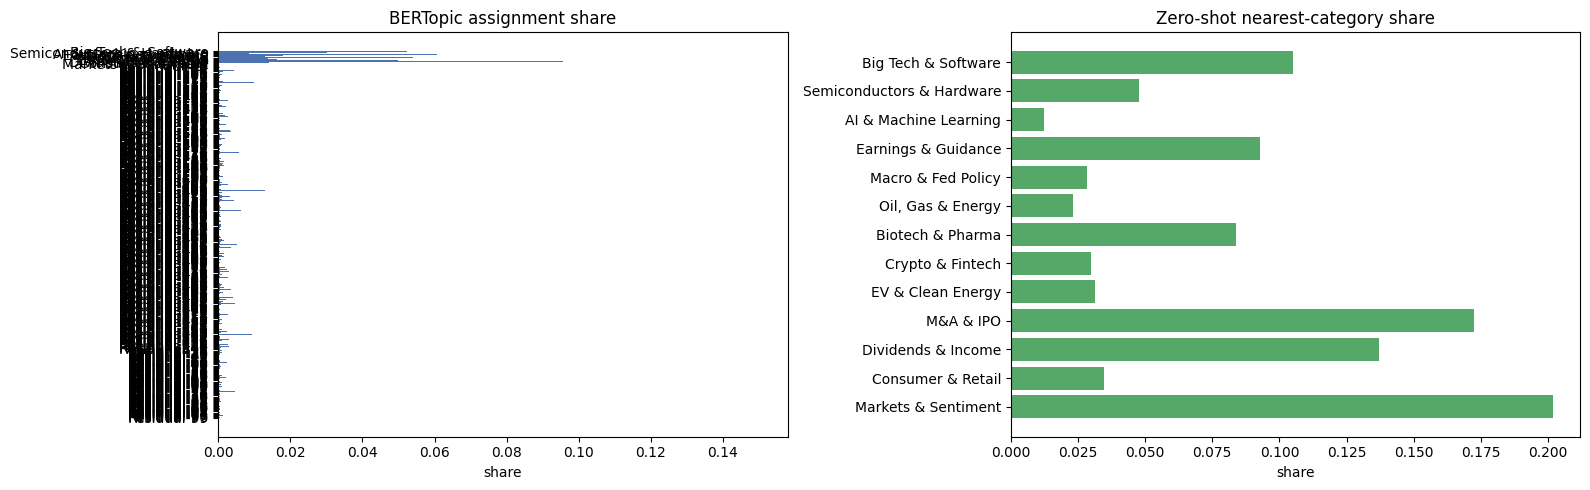

In [10]:
# (a) BERTopic assignments
bert_labels = np.array([internal_to_label[t] for t in topics])

# (b) Pure zero-shot: nearest category embedding per doc.
cat_emb = embed_model.encode(zeroshot_list, normalize_embeddings=True).astype('float32')
doc_emb_n = embeddings / (np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-9)
sim = doc_emb_n @ cat_emb.T            # (N, 13)
zshot_ids = sim.argmax(axis=1)
zshot_labels = np.array([TOPIC_LABELS[i] for i in zshot_ids])


def share(labels: np.ndarray, order: list[str]) -> list[float]:
    counts = {l: 0 for l in order}
    for l in labels:
        counts[l] = counts.get(l, 0) + 1
    total = len(labels)
    return [counts.get(l, 0) / total for l in order]


all_order = ordered_labels + ['Outlier', *sorted({l for l in bert_labels if l not in ordered_labels and l != 'Outlier'})]
bert_share  = share(bert_labels,  all_order)
zshot_share = share(zshot_labels, ordered_labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].barh(all_order, bert_share, color='#4c72b0')
axes[0].set_title('BERTopic assignment share'); axes[0].invert_yaxis()
axes[0].set_xlabel('share')

axes[1].barh(ordered_labels, zshot_share, color='#55a868')
axes[1].set_title('Zero-shot nearest-category share'); axes[1].invert_yaxis()
axes[1].set_xlabel('share')
plt.tight_layout(); plt.show()

## 5. 2D cluster visualisation coloured by the 13 categories

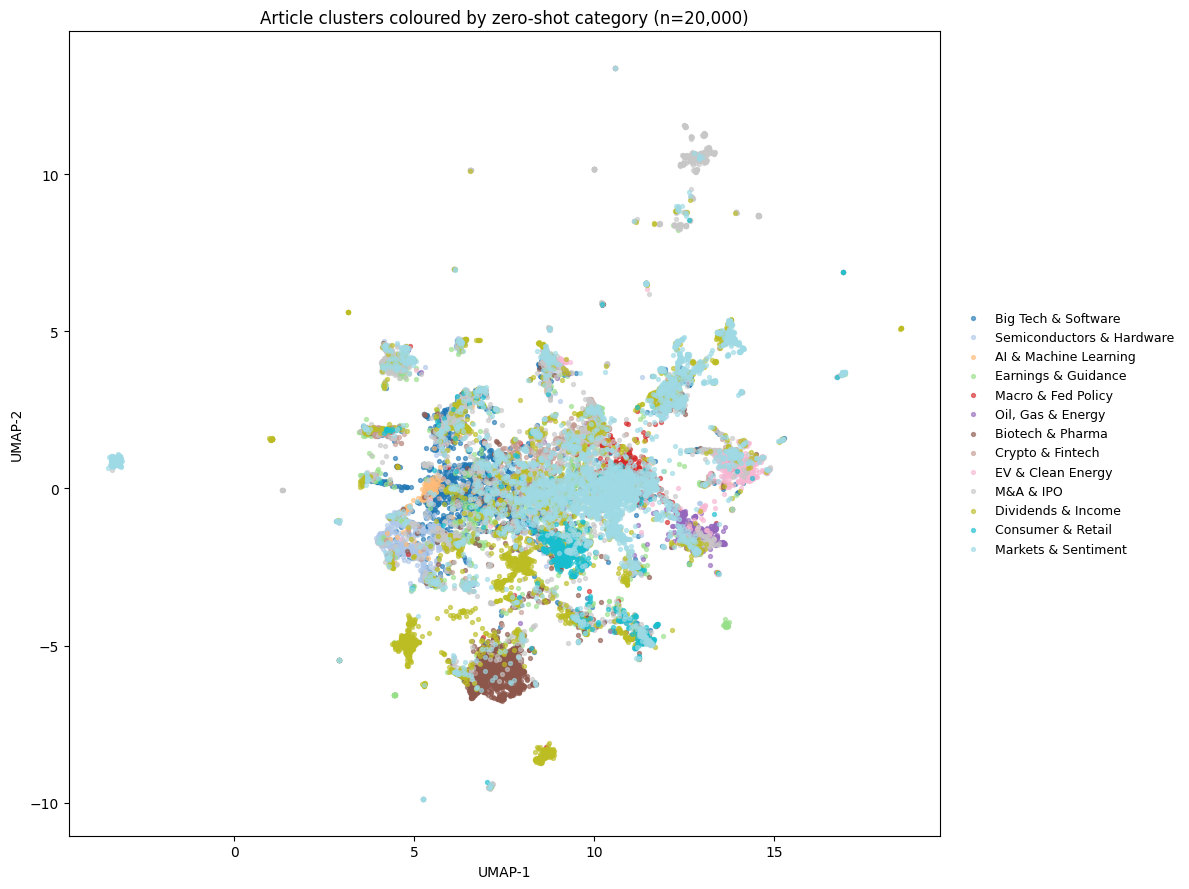

In [11]:
MAX_VIZ = 20_000
if n_docs > MAX_VIZ:
    rng = np.random.default_rng(42)
    sel = rng.choice(n_docs, size=MAX_VIZ, replace=False)
else:
    sel = np.arange(n_docs)

viz_emb = embeddings[sel]
viz_labels = zshot_labels[sel]

umap_2d = UMAP(n_components=2, metric='cosine', random_state=42,
               n_neighbors=min(15, len(sel) - 1), low_memory=True)
coords = umap_2d.fit_transform(viz_emb)

cmap = plt.cm.get_cmap('tab20', len(ordered_labels))
label_to_color = {lbl: cmap(i) for i, lbl in enumerate(ordered_labels)}

fig, ax = plt.subplots(figsize=(12, 9))
for lbl in ordered_labels:
    m = viz_labels == lbl
    if m.any():
        ax.scatter(coords[m, 0], coords[m, 1], s=8, alpha=0.6,
                   color=label_to_color[lbl], label=lbl)
ax.set_title(f'Article clusters coloured by zero-shot category (n={len(sel):,})')
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=9, frameon=False)
plt.tight_layout(); plt.show()

## 6. Save the BERTopic model

In [12]:
topic_model.save(
    str(TOPIC_MODEL_DIR),
    serialization='safetensors',
    save_ctfidf=True,
    save_embedding_model=str(EMBED_DIR),
)
print(f'Saved → {TOPIC_MODEL_DIR}')

Saved → /Users/armandhubler/Documents/coding_project/nlp_project/models/bertopic_zeroshot


## 7. Inference — per-category probability for new text

Wraps the zero-shot path (cosine sim against the 13 category embeddings, softmax) in a minimal class so it's reusable outside the notebook.

In [13]:
class ZeroShotTopicClassifier:
    """Maps text → probability vector over the fixed label set."""

    def __init__(self, embed_model, labels: dict[int, str], descriptions: dict[int, str], temperature: float = 20.0):
        self.embed = embed_model
        self.ids = sorted(labels)
        self.labels = [labels[i] for i in self.ids]
        self.temperature = temperature
        self.cat_emb = embed_model.encode(
            [descriptions[i] for i in self.ids], normalize_embeddings=True
        ).astype('float32')

    def predict_proba(self, texts: list[str]) -> np.ndarray:
        """Return (len(texts), n_labels) probability matrix."""
        q = self.embed.encode(texts, normalize_embeddings=True).astype('float32')
        sim = q @ self.cat_emb.T
        logits = sim * self.temperature
        logits -= logits.max(axis=1, keepdims=True)
        exp = np.exp(logits)
        return exp / exp.sum(axis=1, keepdims=True)

    def predict(self, texts: list[str], top_k: int = 3) -> list[list[tuple[str, float]]]:
        """Top-k (label, prob) per text."""
        probs = self.predict_proba(texts)
        out = []
        for p in probs:
            idx = np.argsort(-p)[:top_k]
            out.append([(self.labels[i], float(p[i])) for i in idx])
        return out


clf = ZeroShotTopicClassifier(embed_model, TOPIC_LABELS, TOPIC_DESCRIPTIONS)
print('Classifier ready over', len(clf.labels), 'categories')

Classifier ready over 13 categories


In [14]:
examples = [
    'Nvidia crushes Q2 earnings as data-center GPU demand explodes; raises full-year guidance',
    'FDA grants accelerated approval for novel oncology therapy after positive phase 3 trial',
    'Fed holds rates steady but signals one more hike as core CPI stays sticky',
    'Bitcoin rallies past $70k on spot ETF inflows, Coinbase shares jump',
    'Exxon to acquire Pioneer Natural Resources in $60 billion all-stock deal',
]

for text, preds in zip(examples, clf.predict(examples, top_k=3)):
    print('\n•', text)
    for lbl, prob in preds:
        print(f'    {lbl:<28} {prob:.3f}')


• Nvidia crushes Q2 earnings as data-center GPU demand explodes; raises full-year guidance
    Semiconductors & Hardware    0.590
    Earnings & Guidance          0.151
    Consumer & Retail            0.045

• FDA grants accelerated approval for novel oncology therapy after positive phase 3 trial
    Biotech & Pharma             0.999
    Earnings & Guidance          0.001
    Dividends & Income           0.000

• Fed holds rates steady but signals one more hike as core CPI stays sticky
    Macro & Fed Policy           0.984
    Markets & Sentiment          0.004
    Crypto & Fintech             0.004

• Bitcoin rallies past $70k on spot ETF inflows, Coinbase shares jump
    Markets & Sentiment          0.410
    Crypto & Fintech             0.279
    Dividends & Income           0.084

• Exxon to acquire Pioneer Natural Resources in $60 billion all-stock deal
    Oil, Gas & Energy            0.915
    M&A & IPO                    0.043
    Biotech & Pharma             0.009


## **Inference on full df**

In [27]:
import pyarrow as pa
import pyarrow.parquet as pq

prob_cols = [
    "prob_" + lbl.lower().replace("&", "and").replace(",", "").replace(" ", "_")
    for lbl in clf.labels
]

OUT_PATH = DATA_DIR / "full_df_topic_probabilities.parquet"
schema = pa.schema([("id", pa.uint32())] + [(c, pa.float32()) for c in prob_cols])
writer = pq.ParquetWriter(str(OUT_PATH), schema=schema, compression="zstd")

BATCH_SIZE = 5000
ids = work["id"].to_numpy()

for start in tqdm(range(0, len(docs), BATCH_SIZE)):
    end = min(start + BATCH_SIZE, len(docs))
    batch_docs = docs[start:end]
    batch_ids  = ids[start:end]

    probs = clf.predict_proba(batch_docs).astype("float32")

    data = {"id": batch_ids.astype("uint32")}
    for j, col in enumerate(prob_cols):
        data[col] = probs[:, j]

    writer.write_table(pa.table(data, schema=schema))

writer.close()

  0%|          | 0/28 [00:00<?, ?it/s]

## **Create a new topic and measure the distance**

In [ ]:
def find_closest_articles(query: str, top_n: int = 10) -> pl.DataFrame:
    # Embed and normalise the query
    q = embed_model.encode([query], normalize_embeddings=True).astype("float32")

    # Cosine sim against all article embeddings (already computed)
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-9
    normed = embeddings / norms
    sims = (normed @ q.T).squeeze()  # shape (N,)

    top_idx = np.argsort(-sims)[:top_n]

    return pl.DataFrame({
        "score": sims[top_idx],
        "doc":   [docs[i] for i in top_idx],
        "id":    work["id"].to_numpy()[top_idx].tolist(),
    })


# Try any topic you want
results = find_closest_articles("central bank policy and inflation expectations", top_n=10)
print(results)

shape: (10, 3)
┌──────────┬─────────────────────────────────┬────────┐
│ score    ┆ doc                             ┆ id     │
│ ---      ┆ ---                             ┆ ---    │
│ f32      ┆ str                             ┆ i64    │
╞══════════╪═════════════════════════════════╪════════╡
│ 0.662372 ┆ [GS] [2023-03-28 00:00:00 UTC]… ┆ 36572  │
│ 0.655056 ┆ [SPY] [2021-11-02 00:00:00 UTC… ┆ 35297  │
│ 0.577163 ┆ [WFC] [2018-09-27 00:00:00 UTC… ┆ 12395  │
│ 0.570745 ┆ [SPY] [2023-04-17 00:00:00 UTC… ┆ 88651  │
│ 0.557193 ┆ [GS] [2021-12-07 00:00:00 UTC]… ┆ 117451 │
│ 0.556323 ┆ [TSLA] [2023-01-03 00:00:00 UT… ┆ 120541 │
│ 0.5536   ┆ [GS] [2022-03-14 00:00:00 UTC]… ┆ 27897  │
│ 0.545719 ┆ [GS] [2021-11-30 00:00:00 UTC]… ┆ 59669  │
│ 0.545567 ┆ [QQQ] [2018-07-12 00:00:00 UTC… ┆ 68419  │
│ 0.541846 ┆ [GS] [2022-03-25 00:00:00 UTC]… ┆ 14094  │
└──────────┴─────────────────────────────────┴────────┘


## 8. Evaluation on a held-out subset of the full df

No labelled ground-truth for the 13 categories exists, so we combine four proxy metrics:

1. **Confidence distribution** - how peaked are the zero-shot probabilities?
2. **Model-agreement** - BERTopic zero-shot assignment vs direct cosine nearest-category (our inference helper). Disagreement signals weak anchoring.
3. **Silhouette score** - cluster separation in 2D UMAP space under the predicted labels.
4. **Hand-labelled gold set** - top-1 and top-3 accuracy on curated queries with known intended category.

Eval subset is disjoint from the working set used for training.

In [21]:
# Build a disjoint eval subset from the full df (not the working set).
N_EVAL = 3000
working_ids = set(work['id'].to_list())
eval_df = (
    df.sample(n=N_EVAL, seed=7)
)
print(f'Eval subset: {eval_df.shape[0]:,} rows (disjoint from working set)')

eval_df = get_summaries(eval_df)
eval_docs, eval_emb = get_embeddings(eval_df)
print(f'Eval docs: {len(eval_docs):,} | embeddings: {eval_emb.shape}')

Eval subset: 3,000 rows (disjoint from working set)
Summaries — cached: 139,522 | need: 0
Embeddings — cached hit: 3,000 / 3,000
Eval docs: 3,000 | embeddings: (3000, 384)


In [22]:
# Predictions from both paths.
eval_probs = clf.predict_proba(eval_docs)      # (N, 13) softmax over cosine sim
eval_zshot_ids = eval_probs.argmax(axis=1)
eval_zshot_labels = np.array([TOPIC_LABELS[i] for i in eval_zshot_ids])

eval_bert_topics, _ = topic_model.transform(eval_docs, embeddings=eval_emb)
eval_bert_labels = np.array([internal_to_label[t] for t in eval_bert_topics])
print('Predictions generated for both BERTopic and zero-shot paths.')

2026-04-12 19:27:14,212 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.


Predictions generated for both BERTopic and zero-shot paths.


Mean top-1 prob : 0.563
Median top-1    : 0.524
  share > 0.30: 87.8%
  share > 0.50: 53.3%
  share > 0.70: 30.6%
  share > 0.90: 10.7%


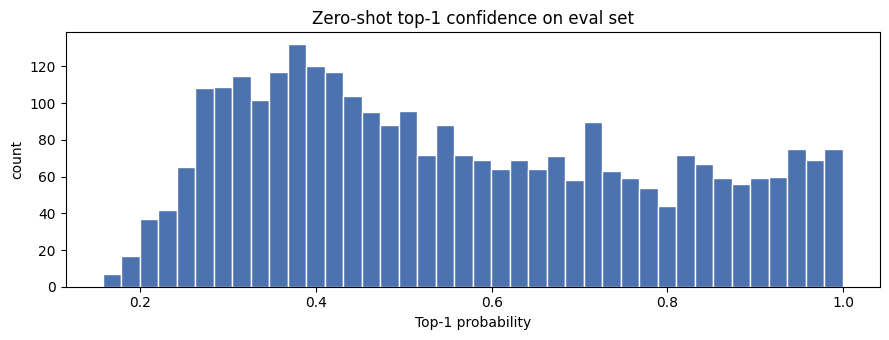

In [23]:
# Metric 1 - confidence distribution of zero-shot top-1 probability.
top1 = eval_probs.max(axis=1)
print(f'Mean top-1 prob : {top1.mean():.3f}')
print(f'Median top-1    : {np.median(top1):.3f}')
for thr in (0.30, 0.50, 0.70, 0.90):
    print(f'  share > {thr:.2f}: {(top1 > thr).mean():.1%}')

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(top1, bins=40, color='#4c72b0', edgecolor='white')
ax.set_xlabel('Top-1 probability'); ax.set_ylabel('count')
ax.set_title('Zero-shot top-1 confidence on eval set')
plt.tight_layout(); plt.show()

In [24]:
# Metric 2 - BERTopic vs zero-shot agreement (restricted to docs BERTopic mapped to a named label).
mask = np.array([l in set(ordered_labels) for l in eval_bert_labels])
agree = (eval_bert_labels[mask] == eval_zshot_labels[mask]).mean()
print(f'BERTopic-named docs : {mask.sum():,} / {len(eval_docs):,}  ({mask.mean():.1%})')
print(f'Label agreement     : {agree:.1%}')

# Per-label agreement breakdown.
rows = []
for lbl in ordered_labels:
    sub = mask & (eval_bert_labels == lbl)
    if sub.sum() == 0:
        continue
    acc = (eval_zshot_labels[sub] == lbl).mean()
    rows.append((lbl, int(sub.sum()), acc))
print()
print(f'{"Category":<28}  n    agree')
for lbl, n, a in rows:
    print(f'{lbl:<28}  {n:>4}  {a:.2f}')

BERTopic-named docs : 674 / 3,000  (22.5%)
Label agreement     : 90.9%

Category                      n    agree
Big Tech & Software             39  0.95
Semiconductors & Hardware       31  0.90
AI & Machine Learning           17  0.88
Earnings & Guidance             82  0.88
Macro & Fed Policy              41  0.73
Oil, Gas & Energy               46  0.80
Biotech & Pharma                73  0.99
Crypto & Fintech                17  0.82
EV & Clean Energy               18  0.94
M&A & IPO                       46  0.80
Dividends & Income             137  1.00
Consumer & Retail               23  0.87
Markets & Sentiment            104  0.93


In [25]:
# Metric 3 - silhouette on zero-shot predictions in 2D UMAP space.
from sklearn.metrics import silhouette_score

umap_eval = UMAP(n_components=2, metric='cosine', random_state=42,
                 n_neighbors=min(15, len(eval_docs) - 1), low_memory=True)
eval_coords = umap_eval.fit_transform(eval_emb)

unique, counts = np.unique(eval_zshot_labels, return_counts=True)
keep_labels = set(unique[counts >= 2])
keep = np.array([l in keep_labels for l in eval_zshot_labels])
if keep.sum() > 10 and len(keep_labels) > 1:
    sil = silhouette_score(eval_coords[keep], eval_zshot_labels[keep], metric='euclidean')
    print(f'Silhouette (2D UMAP, zero-shot labels) : {sil:.3f}')
    print('  interpretation: >0.25 reasonable, >0.5 strong, <0 overlapping')
else:
    print('Not enough per-label samples for silhouette.')

Silhouette (2D UMAP, zero-shot labels) : -0.231
  interpretation: >0.25 reasonable, >0.5 strong, <0 overlapping


In [26]:
# Metric 4 - hand-labelled gold set: top-1 and top-3 accuracy.
GOLD = [
    ('Nvidia H100 GPU shipments strong, data-center revenue hits record',           'Semiconductors & Hardware'),
    ('TSMC raises capex as 3nm wafer demand surges',                                 'Semiconductors & Hardware'),
    ('Microsoft Azure cloud revenue grows 30% on enterprise SaaS adoption',          'Big Tech & Software'),
    ('OpenAI launches new GPT model, enterprise AI adoption accelerates',            'AI & Machine Learning'),
    ('Apple reports Q4 earnings beat with iPhone revenue above estimates',           'Earnings & Guidance'),
    ('Powell signals Fed will keep rates higher for longer amid sticky core CPI',    'Macro & Fed Policy'),
    ('OPEC+ extends production cuts as Brent crude climbs past 90 dollars',          'Oil, Gas & Energy'),
    ('Moderna advances mRNA cancer vaccine after positive phase 2 results',          'Biotech & Pharma'),
    ('Coinbase profits surge as bitcoin ETF inflows push crypto prices higher',      'Crypto & Fintech'),
    ('Tesla cuts EV prices as lithium battery costs decline in Q3',                  'EV & Clean Energy'),
    ('Chevron to acquire Hess in 53 billion all-stock merger deal',                  'M&A & IPO'),
    ('Johnson and Johnson raises quarterly dividend for 61st consecutive year',      'Dividends & Income'),
    ('Walmart holiday sales outlook strong on resilient consumer spending',          'Consumer & Retail'),
    ('S&P 500 hits record high as VIX sinks; bull market rally broadens',            'Markets & Sentiment'),
    ('AMD unveils new data-center MI300 AI accelerator to challenge Nvidia',         'Semiconductors & Hardware'),
]
texts, gold = zip(*GOLD)
gold_top3 = clf.predict(list(texts), top_k=3)
top1 = [p[0][0] for p in gold_top3]
top1_acc = np.mean([p == g for p, g in zip(top1, gold)])
top3_acc = np.mean([g in {l for l, _ in p} for p, g in zip(gold_top3, gold)])
print(f'Gold top-1 accuracy : {top1_acc:.2%}  ({sum(p==g for p,g in zip(top1,gold))}/{len(GOLD)})')
print(f'Gold top-3 accuracy : {top3_acc:.2%}')

check = '✓'
cross = '✗'
head = f'{"pred top-1":<28} | {"expected":<28} | text'
print()
print(head)
for (txt, g), p in zip(GOLD, top1):
    mark = check if p == g else cross
    print(f'{mark} {p:<26} | {g:<28} | {txt[:70]}')

Gold top-1 accuracy : 100.00%  (15/15)
Gold top-3 accuracy : 100.00%

pred top-1                   | expected                     | text
✓ Semiconductors & Hardware  | Semiconductors & Hardware    | Nvidia H100 GPU shipments strong, data-center revenue hits record
✓ Semiconductors & Hardware  | Semiconductors & Hardware    | TSMC raises capex as 3nm wafer demand surges
✓ Big Tech & Software        | Big Tech & Software          | Microsoft Azure cloud revenue grows 30% on enterprise SaaS adoption
✓ AI & Machine Learning      | AI & Machine Learning        | OpenAI launches new GPT model, enterprise AI adoption accelerates
✓ Earnings & Guidance        | Earnings & Guidance          | Apple reports Q4 earnings beat with iPhone revenue above estimates
✓ Macro & Fed Policy         | Macro & Fed Policy           | Powell signals Fed will keep rates higher for longer amid sticky core 
✓ Oil, Gas & Energy          | Oil, Gas & Energy            | OPEC+ extends production cuts as Brent crude c